In [1]:
# ==========================================================
# Notebook 3: Building a TF-IDF Similarity Engine
# ==========================================================

print("Notebook 3: Building a TF-IDF Similarity Engine")

Notebook 3: Building a TF-IDF Similarity Engine


In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [3]:
documents = [
    "Learn Python programming from scratch.",
    "Beginner guide to Artificial Intelligence.",
    "Introduction to Machine Learning.",
    "Top travel destinations in Europe.",
    "Best homemade pizza recipes.",
]

for idx, doc in enumerate(documents, start=1):
    print(f"{idx}. {doc}")

1. Learn Python programming from scratch.
2. Beginner guide to Artificial Intelligence.
3. Introduction to Machine Learning.
4. Top travel destinations in Europe.
5. Best homemade pizza recipes.


In [4]:
query = "How can I start learning AI?"

print("User Query:")
print(query)

User Query:
How can I start learning AI?


In [5]:
vectorizer = TfidfVectorizer()

vectorizer.fit(documents + [query])

print("Vocabulary Size:")
print(len(vectorizer.vocabulary_))

Vocabulary Size:
26


In [6]:
vocab = vectorizer.vocabulary_

for word, idx in list(vocab.items())[:15]:
    print(f"{word:20} -> {idx}")

learn                -> 14
python               -> 19
programming          -> 18
from                 -> 7
scratch              -> 21
beginner             -> 2
guide                -> 8
to                   -> 23
artificial           -> 1
intelligence         -> 12
introduction         -> 13
machine              -> 16
learning             -> 15
top                  -> 24
travel               -> 25


In [7]:
tfidf_matrix = vectorizer.transform(documents + [query])

print("TF-IDF Matrix Shape:")

print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(6, 26)


In [8]:
tfidf_matrix = vectorizer.transform(documents + [query])

print("TF-IDF Matrix Shape:")

print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(6, 26)


In [9]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()
)

tfidf_df

,ai,artificial,beginner,best,can,destinations,europe,from,guide,homemade,...,machine,pizza,programming,python,recipes,scratch,start,to,top,travel
0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.447214,0.000000,0.0,...,0.000000,0.0,0.447214,0.447214,0.0,0.447214,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.462625,0.462625,0.0,0.000000,0.000000,0.000000,0.000000,0.462625,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.379359,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.546779,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.448367,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.0,0.000000,0.447214,0.447214,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.447214,0.447214
4,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.5,...,0.000000,0.5,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.462625,0.000000,0.000000,0.0,0.462625,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.462625,0.000000,0.000000,0.000000


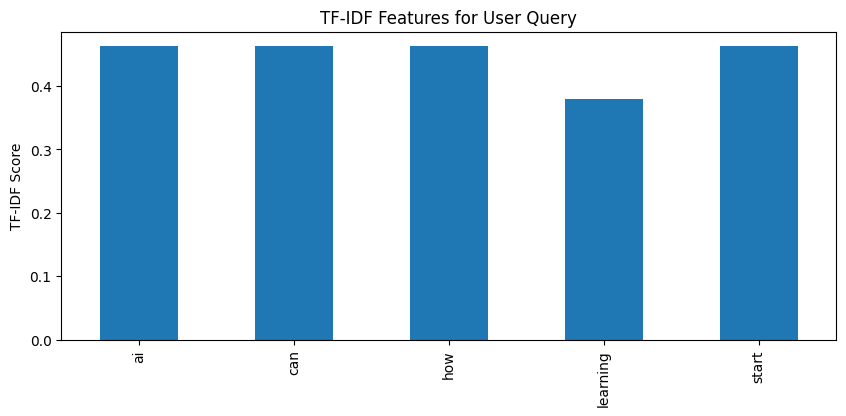

In [10]:
import matplotlib.pyplot as plt

query_vector = tfidf_df.iloc[-1]

query_vector[query_vector > 0].plot(kind="bar", figsize=(10, 4))

plt.title("TF-IDF Features for User Query")

plt.ylabel("TF-IDF Score")

plt.show()

In [11]:
query_vector = tfidf_matrix[-1]

document_vectors = tfidf_matrix[:-1]

similarities = cosine_similarity(query_vector, document_vectors)

print(similarities)

[[0.        0.        0.1700919 0.        0.       ]]


In [12]:
scores = similarities.flatten()

results = pd.DataFrame({"Document": documents, "Similarity": scores})

results = results.sort_values(by="Similarity", ascending=False)

results

,Document,Similarity
2,Introduction to Machine Learning.,0.170092
0,Learn Python programming from scratch.,0.000000
1,Beginner guide to Artificial Intelligence.,0.000000
3,Top travel destinations in Europe.,0.000000
4,Best homemade pizza recipes.,0.000000


In [13]:
print("Top Matching Documents:\n")

for idx, row in results.iterrows():

    print(f"{row['Similarity']:.3f} --> {row['Document']}")

Top Matching Documents:

0.170 --> Introduction to Machine Learning.
0.000 --> Learn Python programming from scratch.
0.000 --> Beginner guide to Artificial Intelligence.
0.000 --> Top travel destinations in Europe.
0.000 --> Best homemade pizza recipes.


In [14]:
def tfidf_search(query, corpus, top_k=3):

    vectorizer = TfidfVectorizer()

    tfidf = vectorizer.fit_transform(corpus + [query])

    query_vector = tfidf[-1]

    doc_vectors = tfidf[:-1]

    scores = cosine_similarity(query_vector, doc_vectors)[0]

    result_df = pd.DataFrame({"Document": corpus, "Similarity": scores})

    result_df = result_df.sort_values(by="Similarity", ascending=False)

    return result_df.head(top_k)

In [15]:
tfidf_search(query="How can I learn AI?", corpus=documents, top_k=3)

,Document,Similarity
0,Learn Python programming from scratch.,0.162329
1,Beginner guide to Artificial Intelligence.,0.000000
2,Introduction to Machine Learning.,0.000000


In [16]:
sentences = [
    "I love machine learning.",
    "I enjoy studying AI.",
    "Deep learning is fascinating.",
    "Pizza tastes delicious.",
    "Traveling is fun.",
]

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(sentences)

similarity_matrix = cosine_similarity(X, X)

similarity_matrix

array([[1.        , 0.        , 0.22001359, 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ],
       [0.22001359, 0.        , 1.        , 0.        , 0.22001359],
       [0.        , 0.        , 0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.22001359, 0.        , 1.        ]])

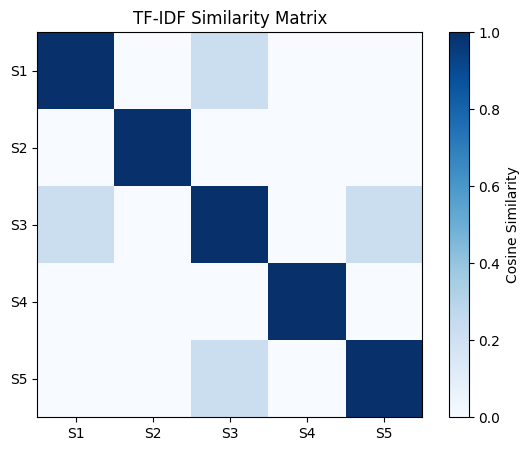

In [17]:
plt.figure(figsize=(7, 5))

plt.imshow(similarity_matrix, cmap="Blues")

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.yticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.title("TF-IDF Similarity Matrix")

plt.show()